# LIFESTYLE DATA EXAMPLE

This is a rough sketch on how to use Undersampling / ClusterCentroids.

We'll elaborate on this during the next lecture.

# Undersampling

In [52]:
# pip install imblearn
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids

df = pd.read_csv("lifestyle_sustainability_data.csv")
df

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
1,2,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,True,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
3,4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
4,5,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,True,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,496,38,Rural,Mostly Plant-Based,Often,Walk,Renewable,House,1789,Sometimes,True,4,High,150,2000,Female,Rarely,Recycling,High,4
495,497,25,Urban,Balanced,Sometimes,Public Transit,Non-Renewable,Apartment,987,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,2
496,498,51,Suburban,Mostly Plant-Based,Always,Bike,Mixed,House,1678,Rarely,True,5,High,280,3200,Non-Binary,Sometimes,Recycling,Moderate,5
497,499,32,Rural,Mostly Plant-Based,Rarely,Walk,Mixed,House,1850,Often,False,1,High,397,4076,Female,Rarely,Recycling,Low,5


In [53]:
# We're not allowed to have NaN values in the dataset once we use undersampling here.
df = df.dropna()

<Axes: xlabel='Rating', ylabel='Count'>

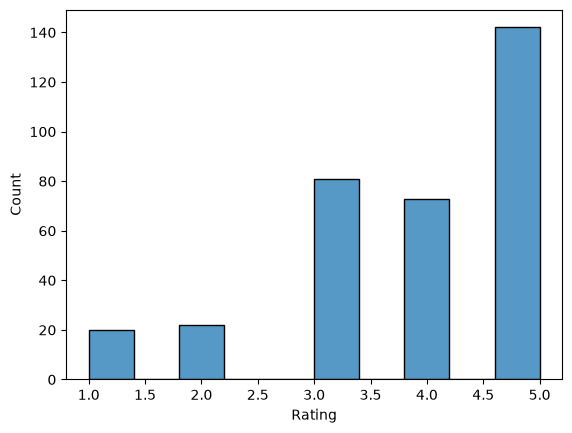

In [54]:
df["Rating"].value_counts()

sns.histplot(df, x="Rating")

In [55]:
from imblearn.under_sampling import RandomUnderSampler

# Split the dataset. If we don't do this, we WILL have a data leakage when training
# the model.
X = df.drop(columns="Rating", axis=1)
y = df["Rating"]

# We set a stable seed for the sampler.
sampler = RandomUnderSampler(random_state=321)

# We use the sampler, and output two variables (X, y respectively).
X_resampled, y_resampled = sampler.fit_resample(X, y)

# Let's make an independent dataframe to be safe.
df_resampled = X_resampled.copy()

# And let's add the `Pop` column back into it.
df_resampled["Rating"] = y_resampled

<Axes: xlabel='Rating', ylabel='Count'>

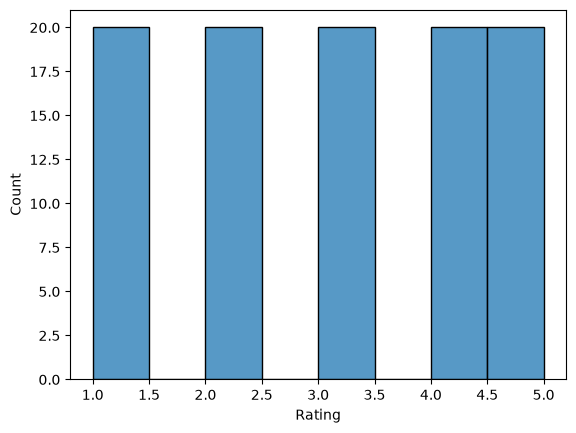

In [56]:
# Viola, undersampled.
sns.histplot(df_resampled, x="Rating")

In [57]:
df_resampled

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
76,77,24,Urban,Mostly Animal-Based,Rarely,Car,Non-Renewable,Apartment,1110,Always,False,2,Low,375,4250,Male,Often,Landfill,Low,1
93,94,33,Urban,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2180,Often,False,2,Low,425,4750,Male,Often,Landfill,Low,1
202,203,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
245,246,56,Suburban,Mostly Animal-Based,Sometimes,Walk,Non-Renewable,Apartment,1594,Sometimes,False,2,High,469,4546,Non-Binary,Often,Recycling,Low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,48,Suburban,Mostly Plant-Based,Often,Bike,Renewable,House,1400,Sometimes,True,5,High,120,1800,Male,Rarely,Composting,High,5
97,98,23,Urban,Mostly Plant-Based,Always,Walk,Renewable,House,1270,Rarely,True,5,High,105,1500,Female,Never,Composting,High,5
328,329,60,Urban,Mostly Plant-Based,Sometimes,Bike,Renewable,House,2941,Rarely,True,4,Moderate,111,3697,Non-Binary,Often,Recycling,Moderate,5
481,482,52,Rural,Mostly Plant-Based,Always,Public Transit,Mixed,House,1567,Rarely,True,5,High,280,3200,Non-Binary,Sometimes,Recycling,Moderate,5


---

# ClusterCentroids

In [59]:
df = pd.read_csv("lifestyle_sustainability_data_processed.csv")

# need to drop NaNs first
df = df.dropna()

<Axes: xlabel='Rating', ylabel='Count'>

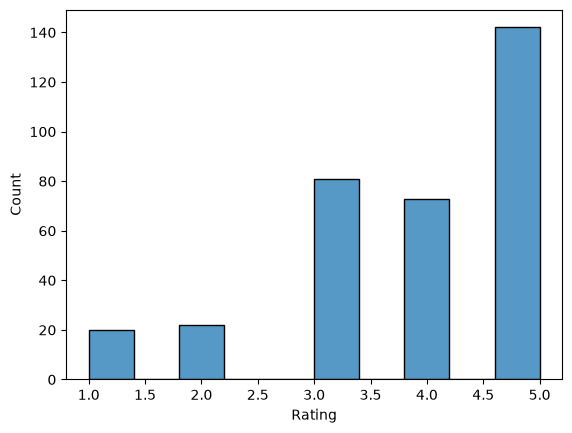

In [60]:
# Show the distribution
sns.histplot(df, x="Rating")

In [61]:
# Another x y split to prevent a data leakage
X = df.drop(columns="Rating", axis=1)
y = df['Rating']

# Here, we tell the sampler what distribution we would like to have.
# Often times, this isn't necessary -- But sometimes it gets rid of far
# too much data if you don't.
strategy = {
    1: 20,
    2: 20,
    3: 30,
    4: 30,
    5: 35
}

sampler = ClusterCentroids(sampling_strategy=strategy, random_state=321)

# perform undersampling
X_resampled, y_resampled = sampler.fit_resample(X, y)

# reconstruct the dataframe
df_resampled = pd.DataFrame(X_resampled)
df_resampled["Rating"] = y_resampled


c:\Users\tuomas.valtanen\dataeng_advda2026_lectures\DataEngineering_AdvDA_2026\.venv\Lib\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (16) found smaller than n_clusters (20). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


<Axes: xlabel='Rating', ylabel='Count'>

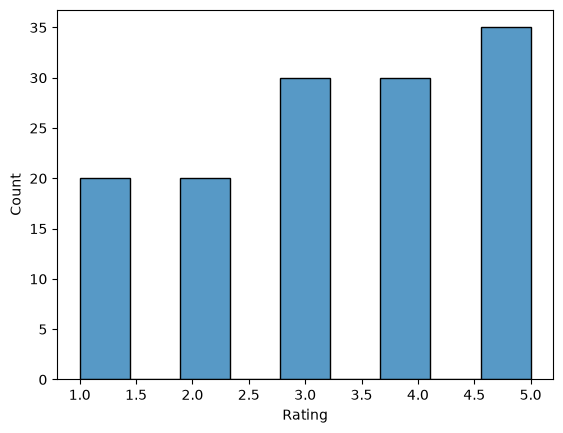

In [62]:
sns.histplot(df_resampled, x="Rating")